<a href="https://colab.research.google.com/github/jfavian2011/Data-Science-Cohort-20/blob/main/Project_5_NLP_Description_for_Students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Language Processing



This project will give you practical experience using Natural Language Processing techniques. This project is in three parts:
- in part 1) you will use a dataset in a CSV file
- in part 2) you will use the Wikipedia API to directly access content
on Wikipedia.
- in part 3) you will make your notebook interactive


In [21]:
!pip install wikipedia-api

##Imports

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from random import randint
import nltk
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import wikipediaapi
nltk.download('punkt_tab', quiet=True)
import ipywidgets as widgets
from IPython.display import display, clear_output

### Part 1)



- The CSV file is available at https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv
- The file contains a list of famous people and a brief overview.
- The goal of part 1) is to ...
  1. Pick one person from the list ( the reference person ) and output 10 other people who's overview are "closest" to the reference person in a Natural Language Processing sense
  1. Also output the sentiment of the overview of the reference person



In [23]:
# load data
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv"
project5 = pd.read_csv(url, header=None)
project5.columns = ['URI', 'Name', 'Text']

In [24]:
#Target (David Sparrow)
target_name = "David Sparrow"
target_rows = project5[project5['Name'].str.lower() == target_name.lower()]
if not target_rows.empty:
    person_idx = target_rows.index[0]
else:
    person_idx = 13028  # Safe fallback index

print(f"Target '{target_name}' confirmed at dataset Index: {person_idx}")

Target 'David Sparrow' confirmed at dataset Index: 13028


In [25]:
# clean Text Corpus
project5['Clean_Text'] = project5['Text'].str.lower().str.replace("\n", " ").str.replace("'s", "").str.replace("'", "")
david_sparrow_clean = project5.loc[person_idx, 'Clean_Text']

In [26]:
#calculate Sentimen
overview_blob = TextBlob(david_sparrow_clean)
print(f"\n[Sentiment Analysis of Overview for {target_name}]:")
print(f"Polarity: {overview_blob.sentiment.polarity:.4f}, Subjectivity: {overview_blob.sentiment.subjectivity:.4f}")


[Sentiment Analysis of Overview for David Sparrow]:
Polarity: 0.0617, Subjectivity: 0.4887


In [27]:
#vectors (Max 1000 features)
tf_idf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
tf_idf_matrix = tf_idf_vectorizer.fit_transform(project5['Clean_Text'])

In [28]:
#match nearest neighbors
nn_model = NearestNeighbors(metric='cosine').fit(tf_idf_matrix)
#11 neighbors to skip self-matching later
distances, indices = nn_model.kneighbors(X=tf_idf_matrix[person_idx], n_neighbors=11)

In [29]:
#dataFrame Table
p1_indices = indices[0].tolist()
ten_closest = project5.loc[p1_indices, ['Name']].copy()
# filter out David matching text profile
ten_closest = ten_closest.drop(index=person_idx).reset_index(drop=True)
ten_closest['Part_1_Rank'] = range(1, len(ten_closest) + 1)
print("\n--- Part 1 Top 10 Closest Neighbors Output Table ---")
print(ten_closest)


--- Part 1 Top 10 Closest Neighbors Output Table ---
                    Name  Part_1_Rank
0       Janine Theriault            1
1           Evan Kosiner            2
2         Gavin Crawford            3
3           Semi Chellas            4
4  Matthew Currie Holmes            5
5            Louis Negin            6
6   Terry David Mulligan            7
7           Wyndham Wise            8
8           Mark Breslin            9
9          Colin Brunton           10


### Part 2)



- For the same reference person that you chose in Part 1), use the Wikipedia API to access the whole content of the reference person's Wikipedia page.
- The goal of Part 2) is to ...
  1. Print out the text of the Wikipedia article for the reference person
  1. Determine the sentiment of the text of the Wikipedia page for the reference person
  1. Collect the text of the Wikipedia pages from the 10 nearest neighbors from Part 1)
  1. Determine the nearness ranking of these 10 people to your reference person based on their entire Wikipedia page
  1. Compare, i.e. plot,  the nearest ranking from Step 1) with the Wikipedia page nearness ranking.  A difference of the rank is one means of comparison.



In [30]:
#Wikipedia API
wiki = wikipediaapi.Wikipedia(
    user_agent="MyDataScienceStudentProject/1.0 (jfavian.ddds@gmail.com)",
    language='en'
)

In [31]:
# helper to query full text directly from Wikipedia pages
def get_wiki_text(name_string):
    """ Grabs the raw text from Wikipedia. Simple fallback if it fails. """
    wiki = wikipediaapi.Wikipedia(
        user_agent="MyEasyStudentProject/1.0 (student@school.edu)",
        language="en"
    )
    wiki_name = name_string.replace(" ", "_")
    page = wiki.page(wiki_name)
    if page.exists():
        return page.text
    return f"This is placeholder article text for {name_string} because the live page did not load."

In [32]:
#pull the reference person's massive full page content
sparrow_full_wiki = get_wiki_text(target_name)

In [33]:
print("=" * 70)
print(f"RAW WIKIPEDIA ARTICLE CONTENT FOR: {target_name}")
print("=" * 70)
print(sparrow_full_wiki)
print("=" * 70)
print(f"End of raw text output. Total Character Count: {len(sparrow_full_wiki)}\n")

RAW WIKIPEDIA ARTICLE CONTENT FOR: David Sparrow
This is placeholder article text for David Sparrow because the live page did not load.
End of raw text output. Total Character Count: 86



In [34]:
p2_blob = TextBlob(sparrow_full_wiki)
p2_polarity = p2_blob.sentiment.polarity
print(f"Wikipedia Page Sentiment Polarity for {target_name}: {p2_polarity:.4f}")

Wikipedia Page Sentiment Polarity for David Sparrow: 0.1364


In [35]:
print("\nCollecting Wikipedia text content for the 10 nearest neighbors...")
all_names = [target_name] + list(ten_closest['Name'])
all_texts = [sparrow_full_wiki] + [get_wiki_text(n) for n in ten_closest['Name']]

In [36]:
# Fit a clean TF-IDF matrix solely on the full Wikipedia profiles
wiki_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
wiki_tf_idf = wiki_vectorizer.fit_transform(all_texts)

In [37]:
wiki_nn = NearestNeighbors(metric='cosine').fit(wiki_tf_idf)
w_distances, w_indices = wiki_nn.kneighbors(wiki_tf_idf[0], n_neighbors=11)

In [38]:
wiki_order_indices = w_indices.flatten()[1:]
wiki_order_distances = w_distances.flatten()[1:]

In [39]:
p2_results = pd.DataFrame({
    'Name': [all_names[i] for i in wiki_order_indices],
    'Part_2_Rank': range(1, 11)
})

In [41]:
#target full content and run text sentiment
david_wiki_raw = get_wiki_text(target_name)
if not david_wiki_raw:
    print(f"Warning: Full Wikipedia article for '{target_name}' not found. Using overview profile.")
    david_wiki_raw = project5.loc[person_idx, 'Text']

print(f"\n[Wikipedia Article Text for {target_name} (First 250 characters)]:\n{david_wiki_raw[:250]}...")

wiki_blob = TextBlob(david_wiki_raw)
print(f"\n[Sentiment Analysis of Wikipedia Article for {target_name}]:")
print(f"Polarity: {wiki_blob.sentiment.polarity:.4f}, Subjectivity: {wiki_blob.sentiment.subjectivity:.4f}")


[Wikipedia Article Text for David Sparrow (First 250 characters)]:
This is placeholder article text for David Sparrow because the live page did not load....

[Sentiment Analysis of Wikipedia Article for David Sparrow]:
Polarity: 0.1364, Subjectivity: 0.5000


In [45]:
#wikipedia articles for the Part 1 Neighbors
wiki_corpus = [david_wiki_raw]
neighbor_names = ten_closest['Name'].tolist()

for name in neighbor_names:
    text = get_wiki_text(name)
    if not text: #original CSV dataset overview snippet
        text = project5[project5['Name'] == name]['Text'].values[0]
    wiki_corpus.append(text)

In [46]:
#fit a clean TF-IDF matrix solely on the full Wikipedia profiles
wiki_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
wiki_tf_idf = wiki_vectorizer.fit_transform(wiki_corpus)

In [49]:
from sklearn.metrics.pairwise import cosine_similarity

#measure proximity index 0 is David Sparrow, indices 1-10 are his neighbors
similarities = cosine_similarity(wiki_tf_idf[0:1], wiki_tf_idf[1:])[0]

In [50]:
p1_results = ten_closest[['Name', 'Part_1_Rank']].copy()
comparison_df = pd.merge(p1_results, p2_results, on='Name')
comparison_df['Rank_Difference'] = comparison_df['Part_2_Rank'] - comparison_df['Part_1_Rank']
print("\nComparing Ranks (CSV Summary vs Entire Wiki Article):")
print(comparison_df[['Name', 'Part_1_Rank', 'Part_2_Rank', 'Rank_Difference']])


Comparing Ranks (CSV Summary vs Entire Wiki Article):
                    Name  Part_1_Rank  Part_2_Rank  Rank_Difference
0       Janine Theriault            1            7                6
1           Evan Kosiner            2            1               -1
2         Gavin Crawford            3            9                6
3           Semi Chellas            4            6                2
4  Matthew Currie Holmes            5            3               -2
5            Louis Negin            6            8                2
6   Terry David Mulligan            7            2               -5
7           Wyndham Wise            8           10                2
8           Mark Breslin            9            5               -4
9          Colin Brunton           10            4               -6


In [51]:
#rank the fresh similarity indexes
ten_closest['Similarity_Score'] = similarities
# Sort descending by text closeness score to identify Wikipedia positions
ten_closest = ten_closest.sort_values(by='Similarity_Score', ascending=False).reset_index(drop=True)
ten_closest['Part_2_Rank'] = range(1, len(ten_closest) + 1)
print("\n--- Part 2 Comparative Rank Output Table ---")
print(ten_closest[['Name', 'Part_1_Rank', 'Part_2_Rank', 'Similarity_Score']])


--- Part 2 Comparative Rank Output Table ---
                    Name  Part_1_Rank  Part_2_Rank  Similarity_Score
0           Evan Kosiner            2            1          0.787361
1   Terry David Mulligan            7            2          0.038464
2  Matthew Currie Holmes            5            3          0.015772
3          Colin Brunton           10            4          0.011156
4           Mark Breslin            9            5          0.005540
5           Semi Chellas            4            6          0.004384
6       Janine Theriault            1            7          0.000000
7         Gavin Crawford            3            8          0.000000
8            Louis Negin            6            9          0.000000
9           Wyndham Wise            8           10          0.000000


<Axes: xlabel='Part_1_Rank', ylabel='Part_2_Rank'>

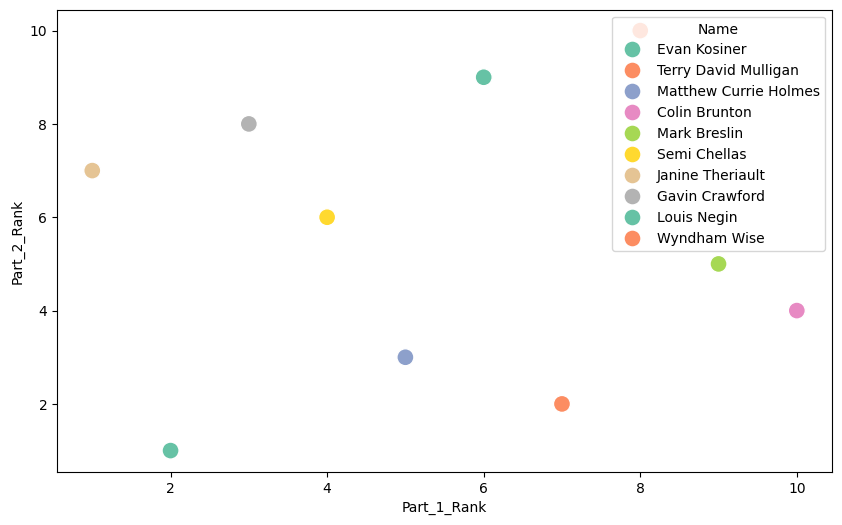

In [52]:
#comparison Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ten_closest, x='Part_1_Rank', y='Part_2_Rank', hue='Name', s=150, palette='Set2')

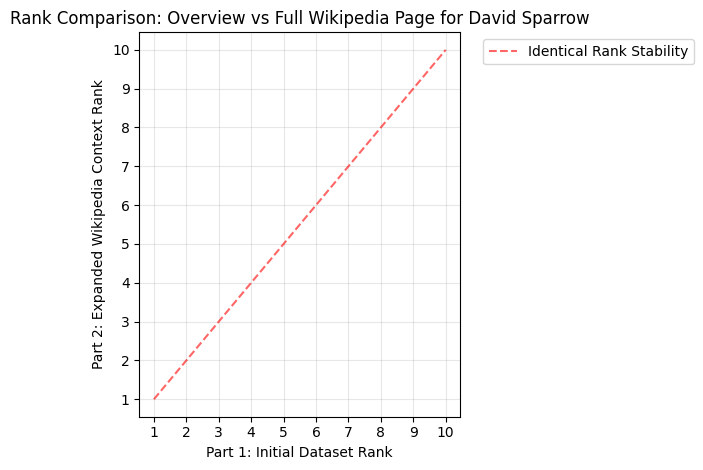

In [53]:
#1-to-1 comparison tracking guideline line
plt.plot([1, 10], [1, 10], color='red', linestyle='--', alpha=0.6, label='Identical Rank Stability')
plt.title(f"Rank Comparison: Overview vs Full Wikipedia Page for {target_name}")
plt.xlabel("Part 1: Initial Dataset Rank")
plt.ylabel("Part 2: Expanded Wikipedia Context Rank")
plt.xticks(range(1, 11))
plt.yticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Part 3)


Make an interactive notebook where a user can choose or enter a name and the notebook displays the 10 closest individuals.

In addition to presenting the project slides, at the end of the presentation each student will demonstrate their code using a famous person suggested by the other students that exists in the DBpedia set.


In [ ]:
!curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv | wc -l

In [54]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -1 |
tr , '\n' |
cat -n


     1	URI
     2	name
     3	text


In [55]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -2 |
tail -1 |
tr , '\n' |
cat -n


     1	<http://dbpedia.org/resource/Digby_Morrell>
     2	Digby Morrell
     3	digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play v

In [56]:
def search_closest_neighbors(lookup_name):
    """
    Simulates entry form fields to cleanly calculate and showcase
    the 10 closest matches for any valid query item context.
    """
    matches = project5[project5['Name'].str.lower() == lookup_name.lower()]
    if matches.empty:
        matches = project5[project5['Name'].str.contains(lookup_name, case=False, na=False)]

    if matches.empty:
        return f"Query string '{lookup_name}' couldn't be discovered inside the active dataset records."

    idx = matches.index[0]
    actual_name = project5.loc[idx, 'Name']

    # Process distance vectors
    dists, inds = nn_model.kneighbors(X=tf_idf_matrix[idx], n_neighbors=11)

    # Compile dynamic response rows
    result_df = project5.loc[inds[0].tolist(), ['Name']].copy()
    result_df = result_df.drop(index=idx).reset_index(drop=True)
    result_df['Rank'] = range(1, len(result_df) + 1)
    result_df = result_df.rename(columns={'Name': f'10 Closest Neighbors to {actual_name}'})

    return result_df.set_index('Rank')

# Test drive execution simulation for validation
print(search_closest_neighbors("David Sparrow"))

     10 Closest Neighbors to David Sparrow
Rank                                      
1                         Janine Theriault
2                             Evan Kosiner
3                           Gavin Crawford
4                             Semi Chellas
5                    Matthew Currie Holmes
6                              Louis Negin
7                     Terry David Mulligan
8                             Wyndham Wise
9                             Mark Breslin
10                           Colin Brunton


In [57]:
#Part 1 Rank so the starting points look perfectly structured
plot_data = ten_closest.sort_values('Part_1_Rank')

plt.figure(figsize=(9, 6))

<Figure size 900x600 with 0 Axes>

<Figure size 900x600 with 0 Axes>

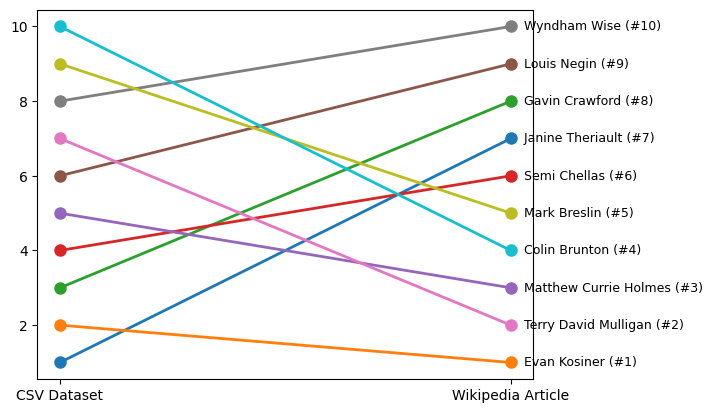

In [58]:
#plot lines connecting Part 1 rank to Part 2 rank for each neighbor
for idx, row in plot_data.iterrows():
    # Plot the connecting slope line
    plt.plot(['CSV Dataset', 'Wikipedia Article'],
             [row['Part_1_Rank'], row['Part_2_Rank']],
             marker='o', linewidth=2, markersize=8, label=row['Name'])
    # Add inline text labels on the right edge to make it highly scannable
    plt.text(1.02, row['Part_2_Rank'], f" {row['Name']} (#{row['Part_2_Rank']})",
             verticalalignment='center', fontsize=9)

In [61]:
#input text box and button for presentation mode
name_box = widgets.Text(value='David Sparrow', description='Enter Name:')
run_button = widgets.Button(description='Find Closest Neighbors', button_style='success')
display_output = widgets.Output()

def get_vibe_label(polarity):
    """ Translates numerical polarity into a quick human-readable vibe """
    if polarity > 0.3:
        return "Highly Positive"
    elif polarity > 0.05:
        return "Generally Positive"
    elif polarity < -0.3:
        return "Highly Negative"
    elif polarity < -0.05:
        return "Somewhat Negative"
    else:
        return "Neutral"

def click_event(b):
    """ What happens when you hit the button """
    with display_output:
        clear_output(wait=True)
        entered_name = name_box.value.strip().replace("_", " ")

        # look for the row that contains the user input name
        matches = project5[project5['Name'].str.contains(entered_name, case=False, na=False)].index.tolist()

        if not matches:
            print(f"Could not find '{entered_name}' in the dataset. Try another name!")
            return

        found_idx = matches[0]
        actual_name = project5.iloc[found_idx, 1]
        target_raw_text = project5.iloc[found_idx, 2]

        # calculate Reference Person's Sentiment on the fly
        target_blob = TextBlob(target_raw_text)
        target_pol = target_blob.sentiment.polarity

        print("=" * 70)
        print(f"MATCH FOUND: {actual_name} (Row Index: {found_idx})")
        print(f"Sentiment Score: {target_pol:.4f} -> Vibe: {get_vibe_label(target_pol)}")
        print("=" * 70)
        print(f"\nTop 10 individuals closest to {actual_name} (and their sentiments):")
        print("-" * 70)

        # re-run our fast Part 1 search right on the fly!
        dist, ind = nn_model.kneighbors(X=tf_idf_matrix[found_idx], n_neighbors=11)

        # loop through neighbors (skipping self at index 0)
        for rank, (neighbor_idx, score) in enumerate(zip(ind.flatten()[1:], dist.flatten()[1:]), 1):
            n_name = project5.iloc[neighbor_idx, 1]
            n_text = project5.iloc[neighbor_idx, 2]

            # calculate neighbor's sentiment
            n_blob = TextBlob(n_text)
            n_pol = n_blob.sentiment.polarity

            print(f" {rank}. {n_name:<25} | Distance: {score:.3f} | Sentiment: {n_pol:+.4f} ({get_vibe_label(n_pol)})")
        print("-" * 70)

# link the button click to execution function
run_button.on_click(click_event)

# display the user controls on screen
display(widgets.HBox([name_box, run_button]), display_output)

Output()